# 17. 순환신경망의 이해

[Note] 이 노트북은 [Deep Learning with Python](https://www.manning.com/books/deep-learning-with-python?a_aid=keras&a_bid=76564dff)의 제6장 2절의 내용을 일부 수정하여 작성한 것이다.

---

## tensorflow.keras.layers.SimpleRNN을 사용한 첫번째 순환층

* `SimpleRNN`은 다른 모든 Keras 레이어처럼 시퀀스의 뱃치를 처리한다. 즉 (batch_size, timesteps, input_features) 형태의 입력을 받는다.
* Keras의 모든 순환층과 마찬가지로, `SimpleRNN`은 두 가지 모드로 실행될 수 있다:
  - 각 시간 단계에 대한 연속적인 출력의 전체 시퀀스(shape=(batch_size, timesteps, output_features) 형태의 3D 텐서)를 반환
  - 각 입력 시퀀스에 대한 마지막 출력(shape=(batch_size, output_features) 형태의 2D 텐서)을 반환
* 이 두 모드는 `return_sequences` 생성자 인수에 의해 제어된다.
* 예를 들어 보자:

#### 시퀀스에 대한 마지막 출력만 반환(기본값)

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential()
model.add(layers.Embedding(input_dim=10000, output_dim=32))
model.add(layers.SimpleRNN(32))
model.build(input_shape=(None, None)) 
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, None, 32)            │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 32)                  │           2,080 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 322,080 (1.23 MB)

 Trainable params: 322,080 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

#### 시퀀스에 대한 연속적인 출력의 전체 반환

In [3]:
model = models.Sequential()
model.add(layers.Embedding(input_dim=10000, output_dim=32))
model.add(layers.SimpleRNN(32, return_sequences=True))
model.build(input_shape=(None, None)) 
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, None, 32)            │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, None, 32)            │           2,080 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 322,080 (1.23 MB)

 Trainable params: 322,080 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

#### 순환층을 여러층 쌓고자 할 때는 모든 중간 계층이 전체 시퀀스를 반환하도록 해야 한다.

In [4]:
model = models.Sequential()
model.add(layers.Embedding(10000, 32))
model.add(layers.SimpleRNN(32, return_sequences=True))
model.add(layers.SimpleRNN(32, return_sequences=True))
model.add(layers.SimpleRNN(32, return_sequences=True))
model.add(layers.SimpleRNN(32))  # 우리 모델에서는 마지막 순환층은 마지막 출력만 반환하도록 설정.
model.build(input_shape=(None, None))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, None, 32)            │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_3 (SimpleRNN)             │ (None, None, 32)            │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_4 (SimpleRNN)             │ (None, None, 32)            │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_5 (SimpleRNN)             │ (None, None, 32)            │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_6 (SimpleRNN)             │ (None, 32)                  │           2,080 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 328,320 (1.25 MB)

 Trainable params: 328,320 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

### IMDb Movie Review Dataset에서의 감정 분석
이 모델을 사용하여 IMDB movie review 분류 문제에 적용해보자. 우선 데이터 전처리가 필요하다:

In [6]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence

max_features = 10000  # 등장 빈도로 max_features 등까지의 단어들만 특징(feature)으로 고려(어휘의 크기)
maxlen = 500          # 어휘 내 단어들 기준으로 maxlen개가 넘는 context는 잘라버림
batch_size = 32

print('데이터 로딩중...')
(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features)
print(len(input_train), '훈련 시퀀스 개수')
print(len(input_test), '테스트 시퀀스 개수')

print('시퀀스 패딩하기(길이가 maxlen이 되도록 패딩)')
input_train = sequence.pad_sequences(input_train, maxlen=maxlen)
input_test = sequence.pad_sequences(input_test, maxlen=maxlen)
print('input_train shape:', input_train.shape)
print('input_test shape:', input_test.shape)

데이터 로딩중...
25000 훈련 시퀀스 개수
25000 테스트 시퀀스 개수
시퀀스 패딩하기(길이가 maxlen이 되도록 패딩)
input_train shape: (25000, 500)
input_test shape: (25000, 500)


#### SimpleRNN
`Embedding` 층과 한 개의 `SimpleRNN` 층을 갖는 단순한 순환신경망으로 훈련시켜보자:

In [9]:
model = models.Sequential()
model.add(layers.Embedding(max_features, 32))
model.add(layers.SimpleRNN(32))
model.add(layers.Dense(1, activation='sigmoid'))
model.build(input_shape=(None, None))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)              │ (None, None, 32)            │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_11 (SimpleRNN)            │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(optimizer='RMSprop', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(input_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.5599 - loss: 0.6720 - val_accuracy: 0.7248 - val_loss: 0.5495
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.8094 - loss: 0.4328 - val_accuracy: 0.8318 - val_loss: 0.3949
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8691 - loss: 0.3266 - val_accuracy: 0.7910 - val_loss: 0.4410
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.8924 - loss: 0.2801 - val_accuracy: 0.7406 - val_loss: 0.5293
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9021 - loss: 0.2443 - val_accuracy: 0.7632 - val_loss: 0.4963
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9218 - loss: 0.2032 - val_accuracy: 0.8530 - val_loss: 0.3750
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9510 - loss: 0.1380 - val_accuracy: 0.8488 - val_loss: 0.4010
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9711 - loss: 0.0908 - val_accu

#### 훈련 및 검증의 손실 및 정확도 그래프:

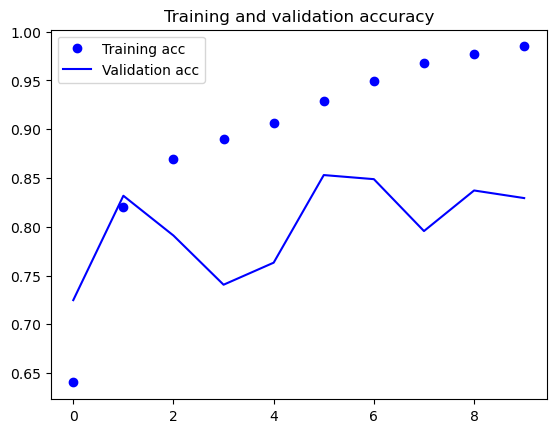

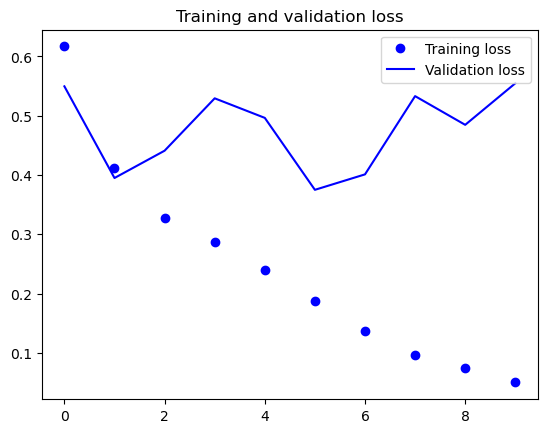

In [11]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

검증 정확도가 최대 85% 수준이며 이것은 기대에 못미친다. 그 원인은:
- 시퀀스 전체가 아닌 처음 500개 단어만 고려한다.
- `SimpleRNN`은 긴 시퀀스를 처리하는 데 그다지 효율적이지 않다.

더 고급의 순환층을 사용해보자.

## tensorflow.keras.layers.LSTM을 사용한 순환층
LSTM 층의 출력 차원만 지정하고, 다른 (많은) 모든 인수는 케라스 기본값에 맡긴다. 케라스는 좋은 기본값을 가지고 있으므로, 매개변수를 직접 조정하는 데 시간을 들이지 않고도 거의 항상 "잘 작동한다".

In [16]:
model = models.Sequential()
model.add(layers.Embedding(max_features, 32))
model.add(layers.LSTM(32))
model.add(layers.Dense(1, activation='sigmoid'))
model.build(input_shape=(None, None))
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ (None, None, 32)            │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer='RMSprop', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(input_train, y_train,
                    epochs=20,
                    batch_size=128,
                    validation_split=0.2)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.5737 - loss: 0.6642 - val_accuracy: 0.7950 - val_loss: 0.4695
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.8136 - loss: 0.4169 - val_accuracy: 0.7806 - val_loss: 0.4830
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - accuracy: 0.8664 - loss: 0.3242 - val_accuracy: 0.8406 - val_loss: 0.4148
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - accuracy: 0.8764 - loss: 0.3073 - val_accuracy: 0.8256 - val_loss: 0.4467
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.8872 - loss: 0.2882 - val_accuracy: 0.8702 - val_loss: 0.3037
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - accuracy: 0.9013 - loss: 0.2583 - val_accuracy: 0.8494 - val_loss: 0.3430
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - accuracy: 0.9156 - loss: 0.2253 - val_accuracy: 0.8630 - val_loss: 0.3268
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.9148 - loss: 0.2206 - 

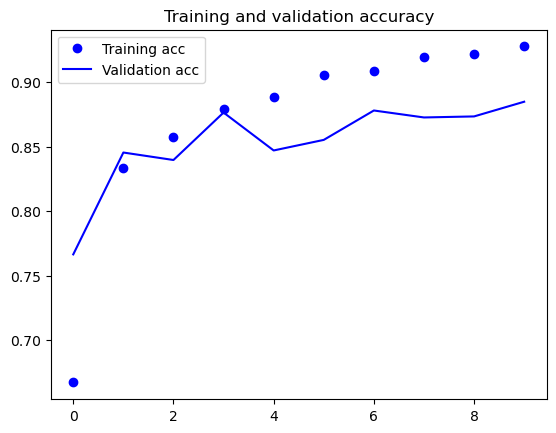

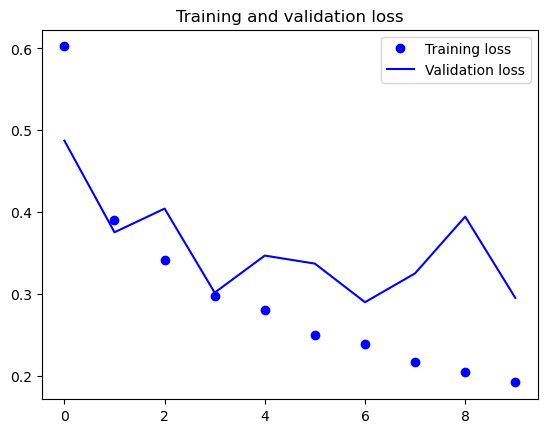

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

LSTM을 사용하여 검증 정확도가 최대 88% 수준으로 개선됐다. 그러나 아직도 기대에 못미친다.
어떻게 하면 성능을 더 높일 수 있을 것인가? 각자 실험해보기 바란다.
- 문맥의 길이 maxlen을 500 보다 길게 한다
- 어휘 집합의 크기를 10000 보다 크게 한다.
- 임베딩 벡터 크기 32 보다 크게 한다.
- 은닉층의 크기를 32 보다 크게 한다.
- 에포크를 더 늘려본다.
- LSTM 층을 더 쌓는다.
- 규제를 적용한다.
- 양방향 순환신경망을 구현해본다.

### 하이퍼파라미터 조정

In [19]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence

max_features = 20000  # 등장 빈도로 max_features 등까지의 단어들만 특징(feature)으로 고려(어휘의 크기)

print('데이터 로딩중...')
(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features)
print(len(input_train), '훈련 시퀀스 개수')
print(len(input_test), '테스트 시퀀스 개수')

데이터 로딩중...
25000 훈련 시퀀스 개수
25000 테스트 시퀀스 개수


In [25]:
max_seq=0
sum_len=0
for i in range(25000):
    l = len(input_train[i])
    sum_len += l
    if l > max_seq:
        max_seq = l
print(max_seq, sum_len/25000)

2494 238.71364


시퀀스의 평균 길이 = 238.7 이고 최대 길이가 2,494 단어인 것을 고려하여,
maxlen = 1000 으로 설정하자. 

In [26]:
maxlen = 1000          # 어휘 내 단어들 기준으로 maxlen개가 넘는 context는 잘라버림
batch_size = 128

print('시퀀스 패딩하기(길이가 maxlen이 되도록 패딩)')
input_train = sequence.pad_sequences(input_train, maxlen=maxlen)
input_test = sequence.pad_sequences(input_test, maxlen=maxlen)
print('input_train shape:', input_train.shape)
print('input_test shape:', input_test.shape)

시퀀스 패딩하기(길이가 maxlen이 되도록 패딩)
input_train shape: (25000, 1000)
input_test shape: (25000, 1000)


In [30]:
model = models.Sequential()
model.add(layers.Embedding(max_features, 64))
model.add(layers.LSTM(64))
model.add(layers.Dense(1, activation='sigmoid'))
model.build(input_shape=(None, None))
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)             │ (None, None, 64)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,313,089 (5.01 MB)

 Trainable params: 1,313,089 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(optimizer='RMSprop', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(input_train, y_train,
                    epochs=20,
                    batch_size=128,
                    validation_split=0.2)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 108s 680ms/step - accuracy: 0.5753 - loss: 0.6627 - val_accuracy: 0.7766 - val_loss: 0.4626
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 104s 665ms/step - accuracy: 0.8120 - loss: 0.4244 - val_accuracy: 0.8520 - val_loss: 0.3599
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 109s 697ms/step - accuracy: 0.8684 - loss: 0.3255 - val_accuracy: 0.8466 - val_loss: 0.3620
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 107s 684ms/step - accuracy: 0.8893 - loss: 0.2824 - val_accuracy: 0.8682 - val_loss: 0.3454
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 109s 697ms/step - accuracy: 0.8984 - loss: 0.2637 - val_accuracy: 0.8672 - val_loss: 0.3323
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 110s 699ms/step - accuracy: 0.9122 - loss: 0.2300 - val_accuracy: 0.8684 - val_loss: 0.3320
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 112s 713ms/step - accuracy: 0.9223 - loss: 0.2079 - val_accuracy: 0.8124 - val_loss: 0.4562
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 110s 698ms/step - accuracy: 0.9280 -

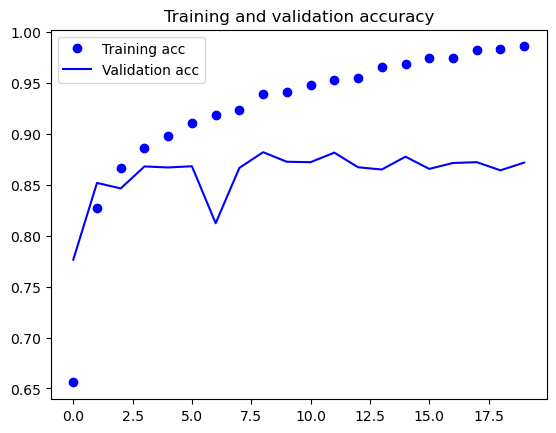

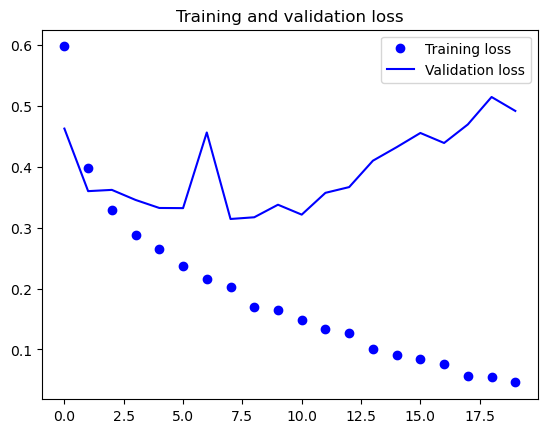

In [32]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

- 그러나, 여전히 검증 정확도가 88% 대를 넘지 못하고 있다. 
- 단순히 크기만 키운 결과, 훈련 시간이 종전 14초/에포크에서 112초/에포크로 늘었다.
- 다른 시도가 필요하다.